This script is written to get atmospheric data (pressure, temperature, etc., as a function of altitude, from a local data file.  The data is then plotted, and fit with a user-defined function

In [78]:
import numpy as np
import matplotlib.pyplot as plt

use_errors = False
fit_type = 1

Define a user funcion for fitting the data.

In [79]:
if fit_type == 1:
    def fitfunction(x,a,b):
        return a*np.exp(b*np.array(x))
else:
    def fitfunction(x,a,b,c):
        return a*np.exp(b*np.array(x)+c*np.power(np.array(x),1.5))

Define python arrays to store the data.

In [80]:
altitude = []
temp = []
gravity = []
pressure = []
density = []
viscosity = []

Read data from the filem and store in the above python arrays.

In [81]:
npoints = 0
with open('density.txt') as f:
    for line in f:
        npoints=npoints+1
        data = line.split()
        altitude.append(float(data[0]))
        temp.append(float(data[1]))
        gravity.append(float(data[2]))
        pressure.append(float(data[3]))
        density.append(float(data[4]))
        viscosity.append(float(data[5]))
        

In [82]:

if use_errors == True:
    # create a list to hold the uncertainty in the density  
    density_uncertainty = [0.01,0.01,0.01,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.0001,0.0001,0.0001,0.00001,0.00001,0.000001,0.0000001,0.0000001]
else:
    density_uncertainty = [0.0]*len(density)
    
density_uncertainty = np.array(density_uncertainty)

Text(0, 0.5, 'Density (kg/m^3)')

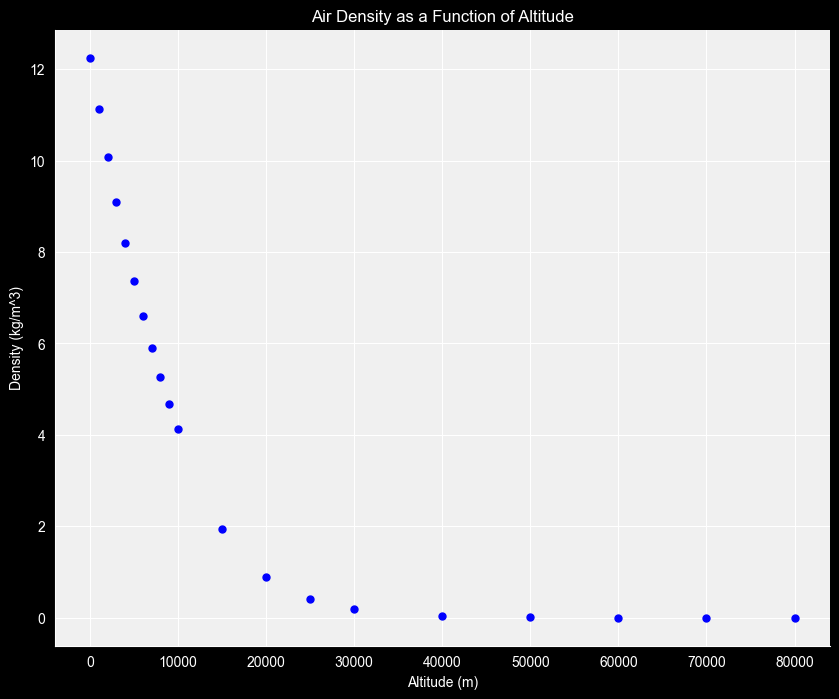

In [83]:
# Create a figure and axes
fig, ax = plt.subplots(figsize=(10, 8))

# Set the grid lines
ax.grid(True)

# Set the background color
ax.set_facecolor('#F0F0F0')

# Set the border properties
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set the line and marker properties
line_color = 'b'
line_width = 0
marker_color = 'b'
marker_style = 'o'
marker_size = 5

# Create the plot
if use_errors == True:
    plt.errorbar(altitude, density, yerr=density_uncertainty, color=line_color, linewidth=line_width,
         marker=marker_style, markersize=marker_size, markerfacecolor=marker_color)
else:
    plt.plot(altitude, density, color=line_color, linewidth=line_width,
         marker=marker_style, markersize=marker_size, markerfacecolor=marker_color)

# Set the plot title and axis labels
plt.title("Air Density as a Function of Altitude")
plt.xlabel("Altitude (m)")
plt.ylabel("Density (kg/m^3)")
#plt.yscale("log")

Fit the data with the pre-defined function

In [84]:
from scipy.optimize import curve_fit

if fit_type == 1:
    init_vals = [12.0,-0.0001]
else:
    init_vals = [12.0,-0.0001, -0.000001]

if use_errors == False:
    popt, pcov = curve_fit(fitfunction, altitude, density, p0=init_vals)
else:
    popt, pcov = curve_fit(fitfunction, altitude, density, sigma=density_uncertainty, absolute_sigma=True, p0=init_vals)

print (popt)
print (pcov)

[ 1.25612159e+01 -1.11851582e-04]
[[ 2.00254127e-02 -2.53509030e-07]
 [-2.53509030e-07  6.46577922e-12]]


In [85]:
yfit = []
chi2=0
for i in range (0,npoints):
    yfit.append(fitfunction(altitude[i],*popt))
    chi2 += (density[i]-yfit[i])*(density[i]-yfit[i])

print ("Chi^2 / dof = %.3E / %d" % (chi2,npoints-len(init_vals)))

Chi^2 / dof = 8.377E-01 / 18


Draw the graph

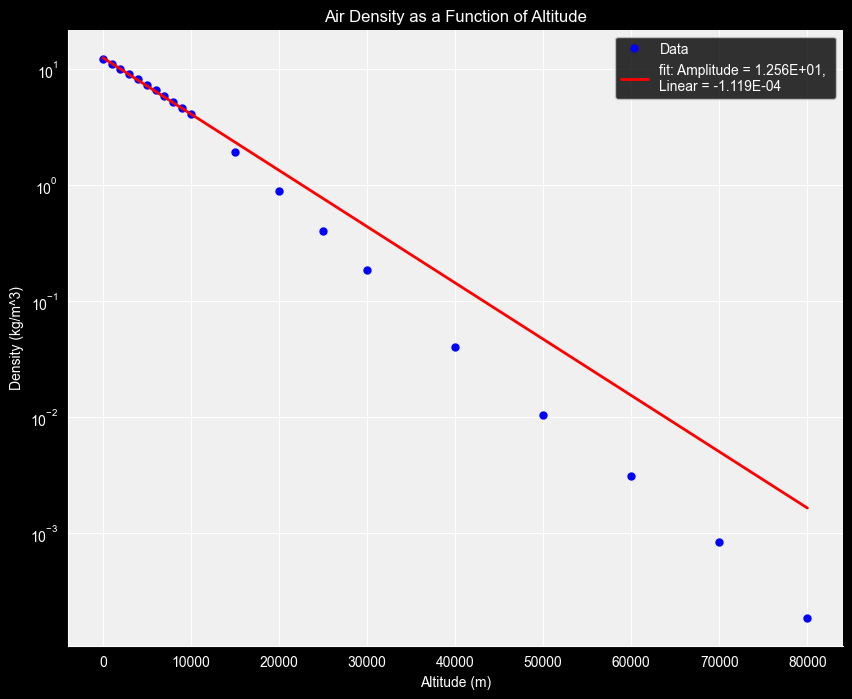

In [86]:
# Create a figure and axes
fig, ax = plt.subplots(figsize=(10, 8))

# Set the grid lines
ax.grid(True)

# Set the background color
ax.set_facecolor('#F0F0F0')

# Set the border properties
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set the line and marker properties
line_color = 'b'
line_width = 0
marker_color = 'b'
marker_style = 'o'
marker_size = 5

# Create the plot
plt.plot(altitude, density, color=line_color, linewidth=line_width,
         marker=marker_style, markersize=marker_size, markerfacecolor=marker_color, label='Data')
if fit_type == 1:
    plt.plot(altitude,yfit,color='r', linewidth=2, label = 'fit: Amplitude = %.3E, \nLinear = %.3E' % tuple(popt))
else:
    plt.plot(altitude,yfit,color='r', linewidth=2, label = 'fit: Amplitude = %.3E, \nLinear = %.3E, \nQuadratic = %.3E' % tuple(popt))

# Set the plot title and axis labels
plt.title("Air Density as a Function of Altitude")
plt.xlabel("Altitude (m)")
plt.ylabel("Density (kg/m^3)")
plt.yscale("log")
plt.legend()

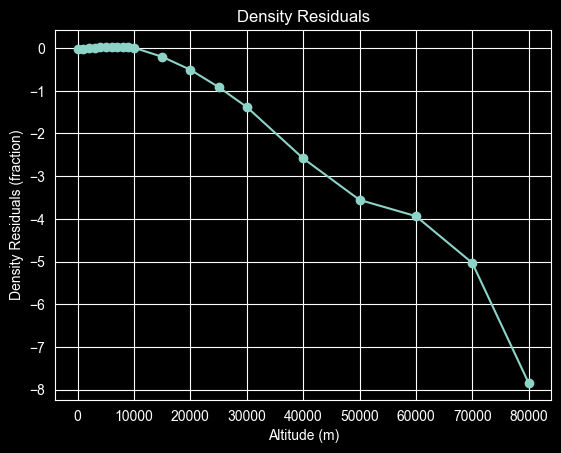

In [87]:
plt.title("Density Residuals")
plt.xlabel('Altitude (m)')
plt.ylabel('Density Residuals (fraction)')
plt.grid(True)

plt.plot(altitude, (density - fitfunction(altitude, *popt))/density, 'o-')

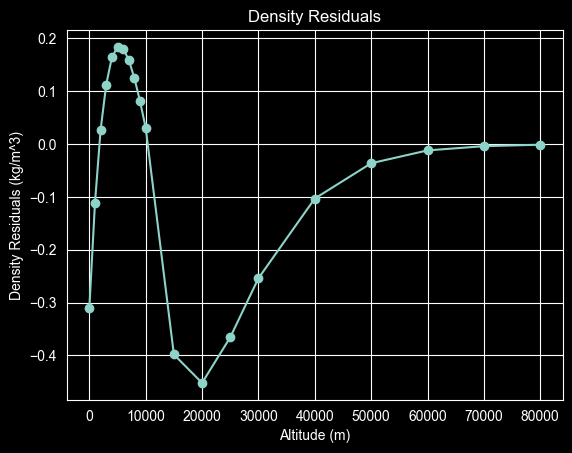

In [88]:
plt.title("Density Residuals")
plt.xlabel('Altitude (m)')
plt.ylabel('Density Residuals (kg/m^3)')
plt.grid(True)

plt.plot(altitude, (density - fitfunction(altitude, *popt)), 'o-')
residuals = (density - fitfunction(altitude, *popt))
popt_exponential = popt

In [89]:
init_vals = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

def residualfunction(x,a,b,c,d,e,f,g,h):
    return a+b*np.power(np.array(x),1)+c*np.power(np.array(x),2)+d*np.power(np.array(x),3)+e*np.power(np.array(x),4)+f*np.power(np.array(x),5)+g*np.power(np.array(x),6)+h*np.power(np.array(x),7)


In [90]:
if use_errors == False:
    popt, pcov = curve_fit(residualfunction, altitude, residuals, p0=init_vals)
else:
    popt, pcov = curve_fit(residualfunction, altitude, residuals, sigma=density_uncertainty, absolute_sigma=True, p0=init_vals)

In [91]:
print (popt, pcov)

[-3.35809864e-01  2.62643186e-04 -4.20314139e-08  2.53492504e-12
 -7.53755544e-17  1.19127736e-21 -9.60947356e-27  3.11523979e-32] [[ 8.68227267e-04 -4.17189271e-07  6.23811161e-11 -4.08024121e-15
   1.35088754e-19 -2.36662053e-24  2.09102449e-29 -7.33109513e-35]
 [-4.17189271e-07  3.15006138e-10 -5.62652340e-14  4.01515608e-18
  -1.39815891e-22  2.53054232e-27 -2.28693633e-32  8.15107989e-38]
 [ 6.23811161e-11 -5.62652340e-14  1.09395985e-17 -8.17002223e-22
   2.92695935e-26 -5.40158265e-31  4.95099788e-36 -1.78355027e-41]
 [-4.08024121e-15  4.01515608e-18 -8.17002223e-22  6.28041206e-26
  -2.29619016e-30  4.30189367e-35 -3.98891136e-40  1.45008881e-45]
 [ 1.35088754e-19 -1.39815891e-22  2.92695935e-26 -2.29619016e-30
   8.52576227e-35 -1.61661353e-39  1.51334594e-44 -5.54376959e-50]
 [-2.36662053e-24  2.53054232e-27 -5.40158265e-31  4.30189367e-35
  -1.61661353e-39  3.09505791e-44 -2.92004193e-49  1.07651778e-54]
 [ 2.09102449e-29 -2.28693633e-32  4.95099788e-36 -3.98891136e-40
   1.

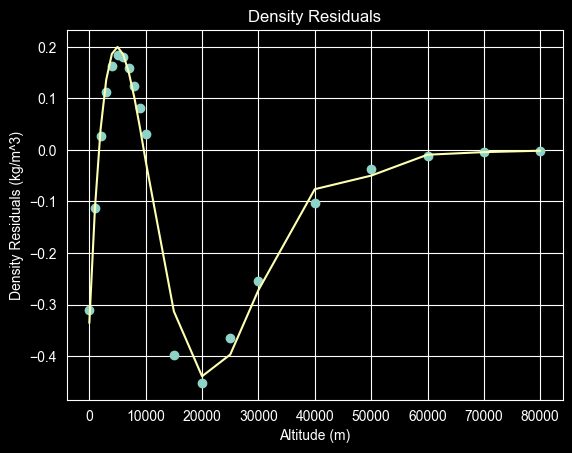

In [92]:
plt.title("Density Residuals")
plt.xlabel('Altitude (m)')
plt.ylabel('Density Residuals (kg/m^3)')
plt.grid(True)


plt.plot(altitude, residuals, 'o')
plt.plot(altitude, residualfunction(altitude, *popt), '-')

In [93]:
popt_combined = [popt_exponential[0], popt_exponential[1], popt[0], popt[1], popt[2], popt[3], popt[4], popt[5], popt[6], popt[7]]

In [94]:
def fitfunction_combined(x,a0,a1,a,b,c,d,e,f,g,h):
    return a0*np.exp(a1*np.array(x))+a+b*np.power(np.array(x),1)+c*np.power(np.array(x),2)+d*np.power(np.array(x),3)+e*np.power(np.array(x),4)+f*np.power(np.array(x),5)+g*np.power(np.array(x),6)+h*np.power(np.array(x),7)

In [95]:
init_vals = popt_combined
if use_errors == False:
    popt, pcov = curve_fit(fitfunction_combined, altitude, density, p0=init_vals)
else:
    popt, pcov = curve_fit(fitfunction_combined, altitude, density, sigma=density_uncertainty, absolute_sigma=True, p0=init_vals)

In [96]:
print (popt, pcov)

[ 6.83555475e-01 -4.18304497e-04  1.15753306e+01 -9.30197553e-04
  9.30184069e-09  1.41368868e-12 -6.46152315e-17  1.20379547e-21
 -1.06151202e-26  3.64415063e-32] [[ 1.82922651e+00  5.75281472e-04 -1.83839594e+00  4.31286955e-04
  -4.06084205e-08  1.97233468e-12 -5.34583043e-17  8.13696226e-22
  -6.48835182e-27  2.10575722e-32]
 [ 5.75281472e-04  1.88483992e-07 -5.79716055e-04  1.34256075e-07
  -1.24763285e-11  5.98966998e-16 -1.60776172e-20  2.42786043e-25
  -1.92350423e-30  6.20983800e-36]
 [-1.83839594e+00 -5.79716055e-04  1.84865359e+00 -4.33513551e-04
   4.08035477e-08 -1.98125167e-12  5.36882582e-17 -8.17058715e-22
   6.51431055e-27 -2.11396397e-32]
 [ 4.31286955e-04  1.34256075e-07 -4.33513551e-04  1.02202001e-07
  -9.67525631e-12  4.72272283e-16 -1.28549996e-20  1.96356578e-25
  -1.57025192e-30  5.10823141e-36]
 [-4.06084205e-08 -1.24763285e-11  4.08035477e-08 -9.67525631e-12
   9.22115769e-16 -4.52981116e-20  1.23982115e-24 -1.90258161e-29
   1.52732945e-34 -4.98438293e-40]
 

Chi^2 / dof = 1.152E-02 / 10


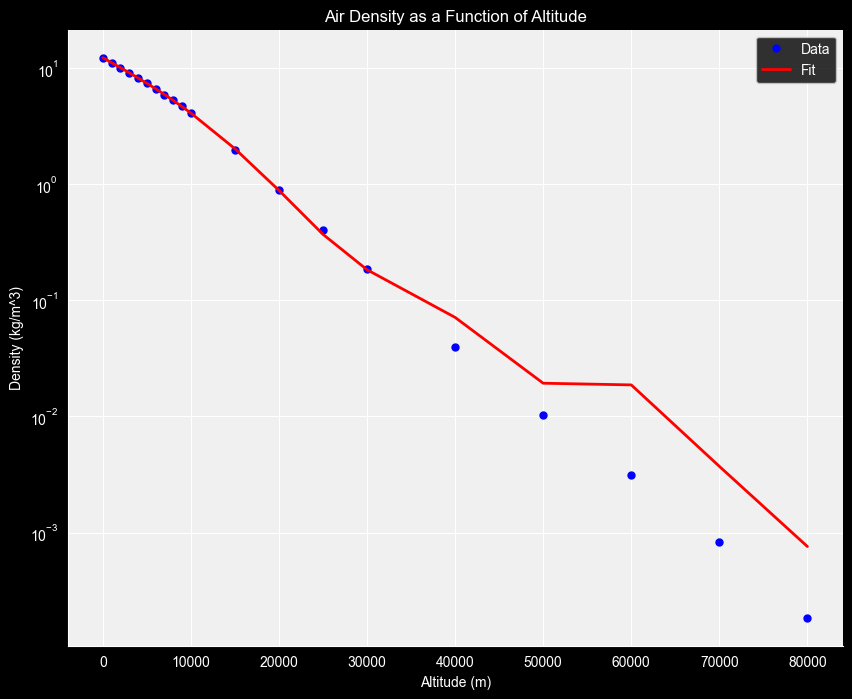

In [98]:
yfit = []
chi2=0
for i in range (0,npoints):
    yfit.append(fitfunction_combined(altitude[i],*popt))
    chi2 += (density[i]-yfit[i])*(density[i]-yfit[i])
    
print ("Chi^2 / dof = %.3E / %d" % (chi2,npoints-len(init_vals)))

# Create a figure and axes
fig, ax = plt.subplots(figsize=(10, 8))

# Set the grid lines
ax.grid(True)

# Set the background color
ax.set_facecolor('#F0F0F0')

# Set the border properties
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set the line and marker properties
line_color = 'b'
line_width = 0
marker_color = 'b'
marker_style = 'o'
marker_size = 5

# Create the plot
plt.plot(altitude, density, color=line_color, linewidth=line_width,
         marker=marker_style, markersize=marker_size, markerfacecolor=marker_color, label='Data')

plt.plot(altitude,np.abs(yfit),color='r', linewidth=2, label = "Fit")

# Set the plot title and axis labels
plt.title("Air Density as a Function of Altitude")
plt.xlabel("Altitude (m)")
plt.ylabel("Density (kg/m^3)")
plt.yscale("log")
plt.legend()